# Learning Probability Density Functions using Non-Linear Transformation



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Dataset

The dataset used is the India Air Quality dataset.  
The feature selected for analysis is NO2 concentration.

Missing values are removed before further processing.


In [2]:
df = pd.read_csv("/india_air_quality.csv", encoding="latin1")
print(df.columns)

x = df["no2"].dropna().values
print("Number of NO2 samples: ", len(x))

/tmp/ipython-input-1254519292.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/india_air_quality.csv", encoding="latin1")


Index(['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type',
       'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5',
       'date'],
      dtype='object')
Number of NO2 samples:  419509


## Non-linear Transformation

Each NO2 value x is transformed into z using:

z = x + a_r sin(b_r x)

where:

a_r = 0.05 (r mod 7)  
b_r = 0.3 (r mod 5 + 1)  

and r is roll number.

This transformation introduces non-linearity and changes the shape of the statistical distribution.


In [3]:
r = 102303764
a_r = 0.05 * (r % 7)
b_r = 0.3 * (r % 5 + 1)

print("a_r = ", a_r)
print("b_r = ", b_r)

a_r =  0.15000000000000002
b_r =  1.5


In [4]:
z = x + a_r * np.sin(b_r * x)
print("First 10 transformed values (z): ")
print(z[:10])

First 10 transformed values (z): 
[17.52349995  6.86804564 28.35851188 14.69117738  7.3548288  25.81277994
 17.17417491  8.76974931 23.00862312  9.00587824]


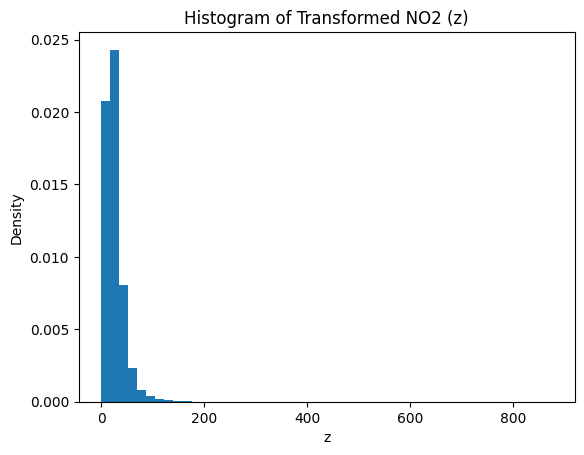

In [5]:
plt.hist(z, bins=50, density=True)
plt.title("Histogram of Transformed NO2 (z)")
plt.xlabel("z")
plt.ylabel("Density")
plt.show()

## Probability Density Function Model

The transformed data z is modeled using:

p̂(z) = c exp(-λ (z - μ)²)

where:

μ is the center of the distribution  
λ controls the spread  
c is a scaling constant


In [6]:
def pdf_model(z, lam, mu, c):
    return c * np.exp(-lam * (z - mu)**2)

## Parameter Estimation using Maximum Likelihood Estimation

The parameters μ and λ are estimated using Maximum Likelihood Estimation.

For the model:

p̂(z) = c exp(-λ (z - μ)²)

the MLE solutions are:

μ = mean(z)  
λ = 1 / (2 Var(z))

The normalization constant c is derived theoretically using:

c = sqrt(λ / π)


In [7]:
mu_est = np.mean(z)
sigma2 = np.var(z)
lambda_est = 1 / (2 * sigma2)
c_est = np.sqrt(lambda_est / np.pi)

print("Final mu:", mu_est)
print("Final lambda:", lambda_est)
print("Final c:", c_est)


Final mu: 25.814687284943872
Final lambda: 0.0014612298133120176
Final c: 0.021566731221112533


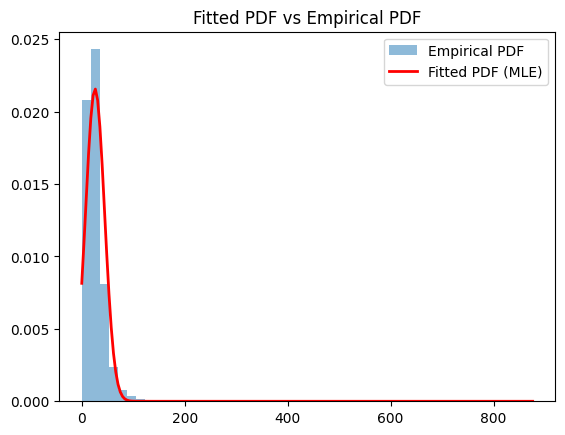

In [8]:
z_fit = np.linspace(min(z), max(z), 200)
p_fit = pdf_model(z_fit, lambda_est, mu_est, c_est)

plt.hist(z, bins=50, density=True, alpha=0.5, label="Empirical PDF")
plt.plot(z_fit, p_fit, 'r-', linewidth=2, label="Fitted PDF (MLE)")
plt.legend()
plt.title("Fitted PDF vs Empirical PDF")
plt.show()